# Priors vs. constant
In the previous notebooks, we have been considering the use of priors, and we have observed that it does improve the fit, especially when combined with the hybrid model, which we took as evidence that participants do rely on priors on top of the decision values to perform the task. However, a potential limitation of our approach is that what we call priors might very well be a specific (and potentially wrong) way of encoding the same thing that could be achieved with constants in Florian's hybrid model.

Indeed, in the previous models, we have assumed that participants behaviour follows a logistic regression parametrized by the decision values (difference in Q values between actions) and the action priors:

Accordingly, we will model the data as:
$$
P(a=0) = \frac{1}{1+e^{-\eta}}
$$

Where:
$$
\eta = \beta DV_{Q} + \beta logit(P(a=1|offer)) + \beta logit(P(a=1|costs)) + \beta logit(P(a=1|transition)) 
$$

Where the $P(a=1|V)$ represents the probability of accepting the offer given the value of each state variables and encodes participants priors of accepting an offer conditional on these state variables. 

However, for offer for example, we have specified two priors:
- $P(a=1|O=1 or 2) = 0.25$
- $P(a=1|O=3 or 4) = 0.75$

The (weighted) logit of those is then combined with the decision values to model participants behaviour. The thing though is that since we have two values, this means that the regressor $logit(P(a=1|offer))$ is just the same as having a binary regressor:

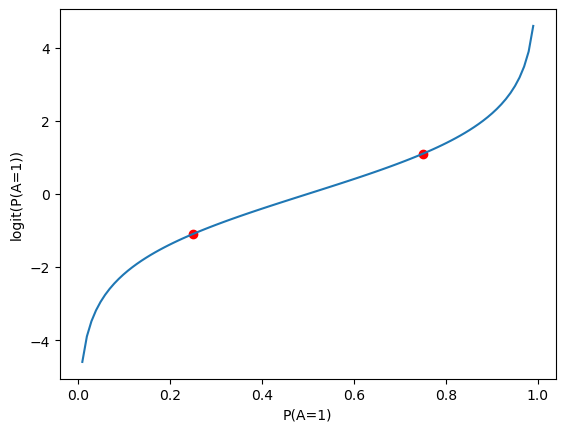

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logit

x = np.linspace(0.01, 0.99, 100)

fig, ax = plt.subplots()
ax.plot(x, logit(x))
ax.scatter([0.25, 0.75], logit([0.25, 0.75]), c='red')
ax.set_ylabel('logit(P(A=1))')
ax.set_xlabel('P(A=1)');

This is visibly very much the same as encoding the high and low offer as 1 and -1 respectively. So the question is then to which extent we can infer whether participants are relying on priors vs. simply showing condition specific biases. To some extent, it is unclear to which extent these two are conceptually different, as one could argue that participants biases reflect their priors.

Another way to ask this question is whether the improve in fit we have seen when adding the costs and transition priors to the hybrid model truly indicates that participants rely on priors, or if adding some information related to these aspects of the task in any form or shape would have increased the fit. More generally, it could be that independent of the idea of prior, adding regressors associated with all dimensions of the task (offer, energy, costs and transitions) would perform the best. 

However, there is one key distinction between the use of the logit of some priors vs. the use of condition specific constants, and that's the spacing between the condition specific values. If we consider a factor with 9 levels, with the following prior:
- $P(a=1|v=1) = 0.1$
- $P(a=1|v=2) = 0.2$
- ...
- $P(a=1|v=9) = 0.9$

then the use of priors vs. of linear constants differs in the following way:

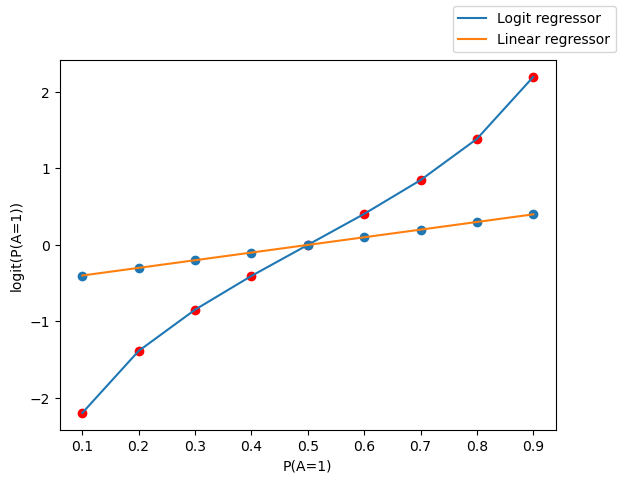

In [2]:
x = np.linspace(0.1, 0.9, 9)

fig, ax = plt.subplots()
ax.plot(x, logit(x), label='Logit regressor')
ax.scatter(x, logit(x), c='red')
ax.plot(x, x - np.mean(x), label='Linear regressor')
ax.scatter(x, x - np.mean(x))
fig.legend()
ax.set_ylabel('logit(P(A=1))')
ax.set_xlabel('P(A=1)');

If participants behaviour reflects the use of priors over the probability of action in specific conditions, we would expect a model in which we encode priors as the logit of that probability should fit the data better than regressors of those conditions. 

This is to some extent the case for the transitions, where we have 4 values. There is an additional distinction between the use of priors and the use of constants. In the hybrid and planning models, a lot of the constants where specified as separate regressors for each conditions. For example, the hybrid model has one regressor for each offer, whereas the offer prior enables specifying a different value for each offer into 1 regressor. Potentially, if the offer specific prior is capable of explaining the same variance as the offer specific regressors, the fit should be increased because the model is less complex.

This second point is less specific to the question of 'priors vs. constants', it is more a question of wether the experimental parameters should be treated as categorical or as continuous regressors. 

In this notebook, we will explore whether the parametrization of the model with our priors outperforms a categorical parametrization with 1 $\beta$ for separate conditions. In addition, we will compare the use of priors vs. continuous regressors to test whether the spacing associated with the logit function applied on the prior performs between than a simple linear value. We will stick to the simpler model before combining regressors to keep things intelligible. 

There are a couple of things to play around with, so I will follow this plan to make sure not to get lost:

| Syntax      | Offer                          | Costs                          | Transitions                    |
| ----------- | -----------                    | -----------                    | -----------                    |
| Priors      | response ~ dv + logit_P_A_offer| response ~ dv + logit_P_A_costs| response ~ dv + logit_P_A_transition|
| Categorical | response ~ dv + is_12 + is_34  | response ~ dv + is_lc + is_hc  | response ~ dv + is_t1 + is_t2 + is_t3 + is_t4  |
| Continuous  | response ~ dv + high_vs_low    | response ~ dv + hc_vs_lc       | response ~ dv + transitions       |

In addition, I will compare the combinations across factors.

# Preparing the data

In [3]:
import pandas as pd
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import arviz as az
import bambi as bmb
from scipy.special import logit
from scipy.stats import entropy

# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute categorical regressors that should be somewhat similar to our priors:
# Categorical offer regressor for high and low offer
data['is_12'] = data['is_1'].to_numpy() + data['is_2'].to_numpy()
data['is_34'] = data['is_3'].to_numpy() + data['is_4'].to_numpy()
# Continuous regressor for high and low offer:
data['high_vs_low'] = data['is_34'] - data['is_12']

# Categorical costs regressor
data['is_lc'] = (data['energy_cost'] == 1).astype(int).to_numpy()
data['is_hc'] = (data['energy_cost'] == 2).astype(int).to_numpy()
# Continuous costs regressor
data['hc_vs_lc'] = data['is_hc'] - data['is_lc']

# Categorical transition regressor
data['is_trans1'] = (data['transition'] == 0).to_numpy()
data['is_trans2'] = (data['transition'] == 1).to_numpy()
data['is_trans3'] = (data['transition'] == 2).to_numpy()
data['is_trans4'] = (data['transition'] == 3).to_numpy()
# Continuous transition regressor
data['transition_centered'] = data['transition'] - 2.5

# Categorical energy regressor:
data['e_is_0'] = (data['energy'] == 0).to_numpy()
data['e_is_1'] = (data['energy'] == 1).to_numpy()
data['e_is_2'] = (data['energy'] == 2).to_numpy()
data['e_is_3'] = (data['energy'] == 3).to_numpy()
data['e_is_4'] = (data['energy'] == 4).to_numpy()
data['e_is_5'] = (data['energy'] == 5).to_numpy()
data['e_is_6'] = (data['energy'] == 6).to_numpy()

# Compute state dependent action priors:

In [ ]:
# ===================================================================
# Coarse offers prior:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if o < 3:
        data.loc[trial_i, 'P(A)-offer'] = 0.25
    else:
        data.loc[trial_i, 'P(A)-offer'] = 0.75

# ===================================================================
# Costs prior
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if cc == 1:
        data.loc[trial_i, 'P(A)-costs'] = 0.75
    elif cc == 2:
        data.loc[trial_i, 'P(A)-costs'] = 0.25

# ===================================================================
# Transition prior
for trial_i, trial in data.iterrows():
    transition = trial.transition
    if transition == 0 or transition == 3:
        data.loc[trial_i, 'P(A)-transition'] = 0.5
    elif transition == 1:
        data.loc[trial_i, 'P(A)-transition'] = 0.25
    elif transition == 2:
        data.loc[trial_i, 'P(A)-transition'] = 0.75

# ===================================================================
# Energy prior
for trial_i, trial in data.iterrows():
    energy, cc = trial.energy, trial.energy_cost
    if energy < cc:
        data.loc[trial_i, 'P(A)-energy'] = 0.01
    elif energy == 6:
        data.loc[trial_i, 'P(A)-energy'] = 0.99
    else:
        data.loc[trial_i, 'P(A)-energy'] = 0.5

# Convert them all to logit:
data["logitP_A_offer"] = logit(data['P(A)-offer'].to_numpy())
data["logitP_A_costs"] = logit(data['P(A)-costs'].to_numpy())
data["logitP_A_transition"] = logit(data['P(A)-transition'].to_numpy())
data["logitP_A_energy"] = logit(data['P(A)-energy'].to_numpy())

# Comparing offer priors to categorical offer regressors

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_offer, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_12, is_34, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_12|vpn_sigma, is_12|vpn_offset, is_34|vpn_sigma, is_34|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 94 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, high_vs_low, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, high_vs_low|vpn_sigma, high_vs_low|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
continuous_offer_model,0,-1778.959894,103.608619,0.000000,1.000000e+00,52.893568,0.000000,True,log
prior_offer_model,1,-1779.650820,104.055594,0.690925,4.302114e-16,52.887552,0.284730,False,log
categorical_offer_model,2,-1779.729799,104.613854,0.769905,4.440892e-16,52.971530,0.467453,False,log


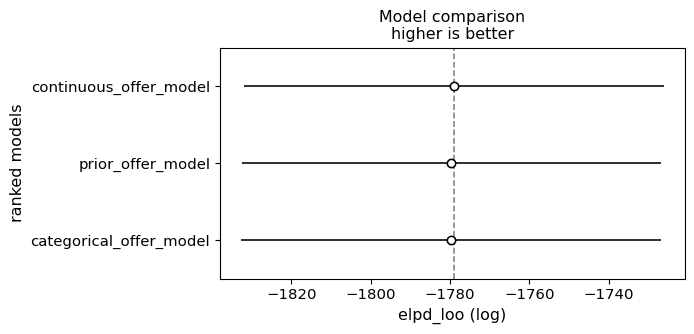

In [5]:
traces = {}

# ===================================================================
# Logistic hierarchical model with offer prior:
prior_offer_model = bmb.Model(
    "response ~ dv + logitP_A_offer + (dv + logitP_A_offer|vpn)", 
    data, 
    family="bernoulli")
traces['prior_offer_model'] = prior_offer_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with categorical offer variables
categorical_offer_model = bmb.Model(
    "response ~ dv + is_12 + is_34 + (dv + is_12 + is_34|vpn)", 
    data, 
    family="bernoulli")
traces['categorical_offer_model'] = categorical_offer_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with continuous offer variables
continuous_offer_model = bmb.Model(
    "response ~ dv + high_vs_low + (dv + high_vs_low|vpn)", 
    data, 
    family="bernoulli")
traces['continuous_offer_model'] = continuous_offer_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

Unsurprinsingly, in the case of offers, we observe that all parametrization perform equally well. The prior model and the continous model are almost exactly the same, as the prior model regressor containts two values, a negative value for the low offer and one positive value for the large offers, same for the continuous prior. The fact that the categorical modles does not perform worst than the two other suggests that the extra cost added by having one more regressor doesn't matter all that much. 

# Comparing costs priors to categorical and continuous costs regressors

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_lc, is_hc, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_lc|vpn_sigma, is_lc|vpn_offset, is_hc|vpn_sigma, is_hc|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 101 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, hc_vs_lc, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, hc_vs_lc|vpn_sigma, hc_vs_lc|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
prior_costs_model,0,-1863.259784,104.237632,0.000000,0.570715,56.549221,0.000000,False,log
categorical_costs_model,1,-1863.365751,104.376046,0.105967,0.429285,56.603328,1.221857,False,log
continuous_costs_model,2,-1863.598664,104.676201,0.338880,0.000000,56.568169,0.311130,True,log


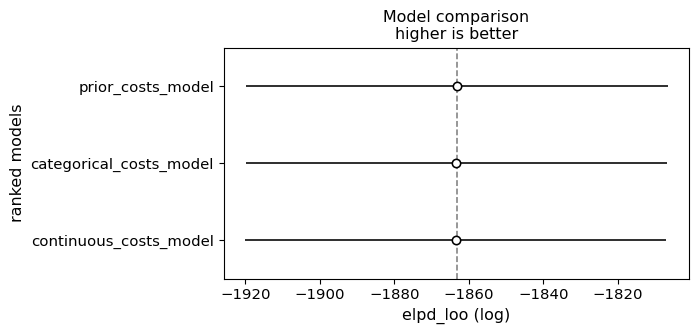

In [6]:
traces = {}

# ===================================================================
# Logistic hierarchical model with costs prior:
prior_costs_model = bmb.Model(
    "response ~ dv + logitP_A_costs + (dv + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['prior_costs_model'] = prior_costs_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with categorical costs variables
categorical_costs_model = bmb.Model(
    "response ~ dv + is_lc + is_hc + (dv + is_lc + is_hc|vpn)", 
    data, 
    family="bernoulli")
traces['categorical_costs_model'] = categorical_costs_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with continuous costs variables
continuous_costs_model = bmb.Model(
    "response ~ dv + hc_vs_lc + (dv + hc_vs_lc|vpn)", 
    data, 
    family="bernoulli")
traces['continuous_costs_model'] = continuous_costs_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

Just in the same way the different parametrization were equivalent for the high and low offers, they are also the same for the costs. This makes a lot of sense as here again, we have only 2 different values, which means that the parametrization with priors is equivalent to the parametrization with ones and -1 for low and hight costs respectively.  

# Comparing transition priors to categorical offer regressors

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_transition, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_transition|vpn_sigma, logitP_A_transition|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_trans1, is_trans2, is_trans3, is_trans4, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_trans1|vpn_sigma, is_trans1|vpn_offset, is_trans2|vpn_sigma, is_trans2|vpn_offset, is_trans3|vpn_sigma, is_trans3|vpn_offset, is_trans4|vpn_sigma, is_trans4|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 95 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, transition_centered, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, transition_centered|vpn_sigma, transition_centered|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 33 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
categorical_transition_model,0,-1834.466781,146.112695,0.000000,6.279410e-01,56.627222,0.000000,False,log
prior_transition_model,1,-1841.746743,104.065769,7.279962,3.720590e-01,56.037331,7.630900,True,log
continuous_transition_model,2,-2060.285341,77.946636,225.818561,8.571694e-15,55.860262,19.768865,False,log


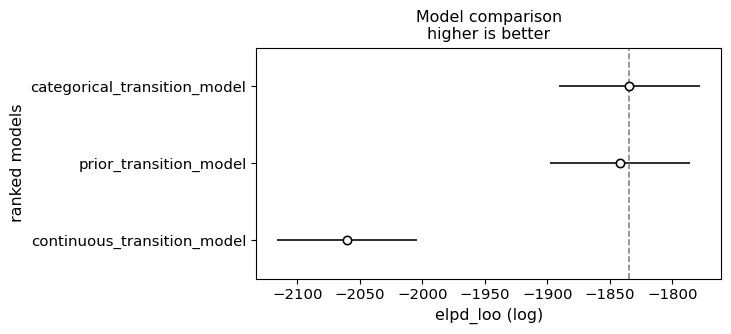

In [7]:
traces = {}

# ===================================================================
# Logistic hierarchical model with transition prior:
prior_transition_model = bmb.Model(
    "response ~ dv + logitP_A_transition + (dv + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['prior_transition_model'] = prior_transition_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with categorical transition variables
categorical_transition_model = bmb.Model(
    "response ~ dv + is_trans1 + is_trans2 + is_trans3 + is_trans4 + (dv + is_trans1 + is_trans2 + is_trans3 + is_trans4|vpn)", 
    data, 
    family="bernoulli")
traces['categorical_transition_model'] = categorical_transition_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with continuous transition variables
continuous_transition_model = bmb.Model(
    "response ~ dv + transition_centered + (dv + transition_centered|vpn)", 
    data, 
    family="bernoulli")
traces['continuous_transition_model'] = continuous_transition_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

In this particular case, the continuous model clearly doesn't fit the data well. This makes a lot of sense, as the transition is clearly a categorical factor, and participants decision should not depend on the arbitrary indices we have defined for each separate transition in a linear fashion. What we see is that the model with priors performs almost equally well as the categorical transition model. My interpretation of this is that the prior we have set for the transition are quite arbitrary, and it could very well be the case that participants use slightly different priors. In contrast, the categorical model is less constraining, it is basically an approximation of letting the model determining which priors the participants might have (that's of course a very opiniated interpretation). However, the fact that the categorical model does not outperform the prior model suggests that the added cost of having 4 regressors instead of 1 pulls it down. It could be that participants do rely on priors in the specific way we have encoded them and that the values we have set are off. 

# Comparing combinations


Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_offer, logitP_A_costs, logitP_A_transition, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset, logitP_A_transition|vpn_sigma, logitP_A_transition|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 49 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_12, is_34, is_lc, is_hc, is_trans1, is_trans2, is_trans3, is_trans4, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_12|vpn_sigma, is_12|vpn_offset, is_34|vpn_sigma, is_34|vpn_offset, is_lc|vpn_sigma, is_lc|vpn_offset, is_hc|vpn_sigma, is_hc|vpn_offset, is_trans1|vpn_sigma, is_trans1|vpn_offset, is_trans2|vpn_sigma, is_trans2|vpn_offset, is_trans3|vpn_sigma, is_trans3|vpn_offset, is_trans4|vpn_sigma, is_trans4|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 286 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, high_vs_low, hc_vs_lc, transition_centered, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, high_vs_low|vpn_sigma, high_vs_low|vpn_offset, hc_vs_lc|vpn_sigma, hc_vs_lc|vpn_offset, transition_centered|vpn_sigma, transition_centered|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
prior_model,0,-1666.068230,149.343499,0.000000,1.0,52.390007,0.000000,True,log
continuous_model,1,-1676.355369,152.095647,10.287139,0.0,52.412347,3.806595,True,log
categorical_model,2,-1683.848258,164.861007,17.780029,0.0,52.632244,3.932176,True,log


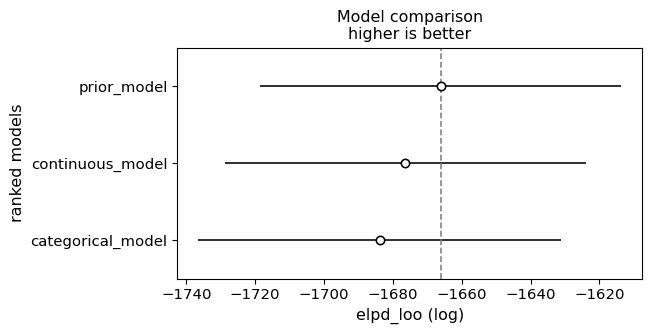

In [8]:
traces = {}

# ===================================================================
# Logistic hierarchical model with combined prior:
prior_model = bmb.Model(
    "response ~ dv + logitP_A_offer + logitP_A_costs + logitP_A_transition + "
    "(dv + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['prior_model'] = prior_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with categorical combined variables
categorical_model = bmb.Model(
    "response ~ dv + is_12 + is_34 + is_lc + is_hc + is_trans1 + is_trans2 + is_trans3 + is_trans4 + "
    "(dv + is_12 + is_34 + is_lc + is_hc + is_trans1 + is_trans2 + is_trans3 + is_trans4|vpn)", 
    data, 
    family="bernoulli")
traces['categorical_model'] = categorical_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Logistic hierarchical model with continuous combined variables
continuous_model = bmb.Model(
    "response ~ dv + high_vs_low + hc_vs_lc + transition_centered + (dv + high_vs_low + hc_vs_lc + transition_centered|vpn)", 
    data, 
    family="bernoulli")
traces['continuous_model'] = continuous_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

These results are quite encouraging. The best fitting model is the one combining all the priors. The interpetation is quite straight forward. While for each separate aspect, the categorical model might not perform all that differently from the model with priors, it has the added costs of having so many more parameters such that when all combined together, they bring it quite down. The fact that the continuous model does not perform as good as the prior model is surely due to the bad performance for the transitions. 

Overall, these results indicate that the use of prior is a quite parsimonious way of encoding the parameters that matter for participants behaviour. And while instead of hard coding the prior values, we can estimate them indirectly by using categorical parameters, the complexity costs associated with doing so brings the fit down, meaning that our use of somewhat reasonable priors performs best.

However, a final question is whether we can use categorical parameters for the aspects of the task for which our priors were not observed to fit the data so well at all, namely energy (and separate regressors for each offers), and whether doing so increases the fit. That is to some extent what has prompted this line of inquiry. Upon noticing that adding costs and transition priors increases the fit, the question popped into my mind of whether that's really indication in favour of the priors or if it was just indication that a model informed about these aspects of the task just generally performs better. 

# Full categorical model

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_offer, logitP_A_costs, logitP_A_transition, logitP_A_energy, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_offer|vpn_sigma, logitP_A_offer|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset, logitP_A_transition|vpn_sigma, logitP_A_transition|vpn_offset, logitP_A_energy|vpn_sigma, logitP_A_energy|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 66 seconds.
Modeling the probability that response==1
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_1, is_2, is_3, is_4, is_lc, is_hc, is_trans1, is_trans2, is_trans3, is_trans4, e_is_0, e_is_1, e_is_2, e_is_3, e_is_4, e_is_5, e_is_6, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset, is_lc|vpn_sigma, is_lc|vpn_offset, is_hc|vpn_sigma, is_hc|vpn_offset, is_trans1|vpn_sigma, is_trans1|vpn_offset, is_trans2|vpn_sigma, is_trans2|vpn_offset, is_trans3|vpn_sigma, is_trans3|vpn_offset, is_trans4|vpn_sigma, is_trans4|vpn_offset, e_is_0|vpn_sigma, e_is_0|vpn_offset, e_is_1|vpn_sigma, e_is_1|vpn_offset, e_is_2|vpn_sigma, e_is_2|vpn_offset, e_is_3|vpn_sigma, e_is_

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 578 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely t

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
full_categorical_model,0,-1511.267012,262.298129,0.000000,0.789461,48.967111,0.000000,True,log
hybrid_prior_mixture_model,1,-1572.329522,213.794854,61.062509,0.026204,50.887886,14.179739,True,log
prior_model,2,-1601.693938,178.541085,90.426926,0.184336,54.186344,21.653988,True,log


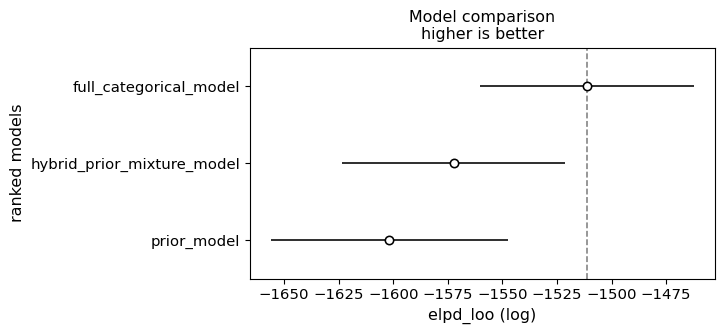

In [ ]:
traces = {}

# ===================================================================
# Logistic hierarchical model with combined prior (added energy for completeness):
prior_model = bmb.Model(
    "response ~ dv + logitP_A_offer + logitP_A_costs + logitP_A_transition + logitP_A_energy +"
    "(dv + logitP_A_offer + logitP_A_costs + logitP_A_transition + logitP_A_energy|vpn)", 
    data, 
    family="bernoulli")
traces['prior_model'] = prior_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# ===================================================================
# Hybrid mixture model (BEST FIT IN PREVIOUS NOTEBOOK)
hybrid_prior_mixture_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer + logitP_A_costs +  logitP_A_transition + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer + logitP_A_costs + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_prior_mixture_model'] = hybrid_prior_mixture_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
    quiet=True
)

# ===================================================================
# Logistic hierarchical model with categorical offer variables
full_categorical_model = bmb.Model(
    "response ~ dv + is_1 + is_2 + is_3 + is_4 + is_lc + is_hc + is_trans1 + is_trans2 + is_trans3 + is_trans4 + " \
    "e_is_0 + e_is_1 + e_is_2 + e_is_3 + e_is_4 + e_is_5 + e_is_6 + "
    "(dv + is_1 + is_2 + is_3 + is_4 + is_lc + is_hc + is_trans1 + is_trans2 + is_trans3 + is_trans4 +e_is_0 + e_is_1 + e_is_2 + e_is_3 + e_is_4 + e_is_5 + e_is_6|vpn)", 
    data, 
    family="bernoulli")
traces['full_categorical_model'] = full_categorical_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True},
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

As I supsected, the full categorical model is the best model we've had so far. It outperforms even the hybrid model enriched with the priors by quite some margin. Of course, that doesn't imply that participants do not rely on state specific priors to take their decisions. In fact, one could make the argument that the fact that the full categorical model approximates the action prior for each of the levels of each factors from our task. The fact that the model with priors only doesn't fit the data as well might just indicate the fact that the priors we have selected just don't reflect participants priors.

However, this is a very heavy handed interpretation, and it is not quite clear how we can make a strong case that participants do use priors. In a sense, we have simply modelled all parameters of the task, which is very much standard practice in linear modelling of experimental tasks, and added the decision values. It would be hard to claim novelty of added priors with such results. What the model shows is that while participants behavior has a planning component captured by our decision values but is further influenced by the experimental parameters. It is quite a leap to say that the influence of experimental parameters is due to the fact that participants rely on action priors.

On the other hand, it is somewhat unclear conceptually how the use of factor related regressors differs from the idea of priors. Indeed, a less loaded interpretation of the fact that the full categorical model fits the data the best is that participants exhibit biases away from optimal planning, and that those biases depend on the experimental parameters. An interpretation of these biases is that they reflect priors. 


# Priors vs. something else

There is however one thing that's specific about the use of priors. As we have seen in the first notebook, when considering that participants behaviour reflects a softmax on the Q function modulated by an action prior, we expect that participants behaviour should reflect a weighted average between the decision values and the logit of the action prior. If that is the case, then we would expect that the condition specific biases in the categorical model should follow a logit function, rather than just a straight line. We can see whether that's the case by plotting the beta values for each experimental conditions as a function of the experimental parameter to see whether they form a straight line or not. 

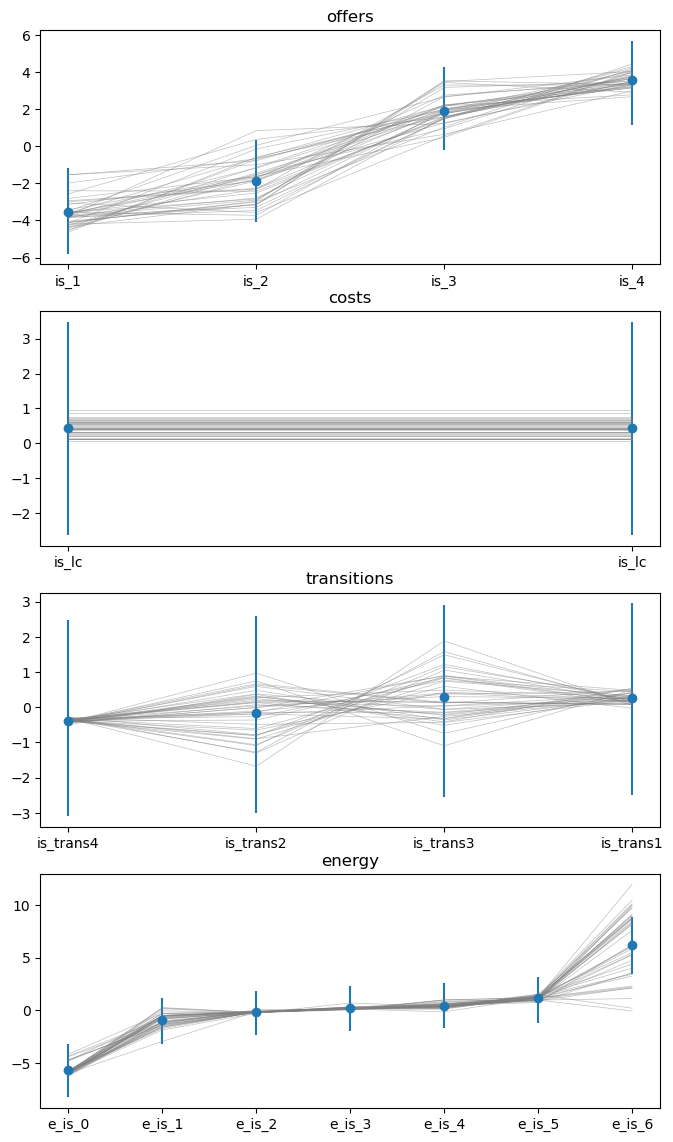

In [ ]:
fig, ax = plt.subplots(4, figsize=[8, 14]);
factors = [
    ['is_1', 'is_2', 'is_3', 'is_4'],
    ['is_lc', 'is_lc'],
    [ 'is_trans4', 'is_trans2', 'is_trans3', 'is_trans1'],
    ['e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6']
]
factors_names = ['offers', 'costs', 'transitions', 'energy']
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}

for i, fact in enumerate(factors):
    subjects_estimates = []
    pop_estimates = []
    pop_hdi = []
    for ii, lvl in enumerate(fact):
        hdi = az.hdi(traces['full_categorical_model'].posterior[f"{lvl}"])[lvl].to_numpy()
        # Convert for error bars
        pop_estimates.append(np.mean(traces['full_categorical_model'].posterior[f"{lvl}"].to_numpy(), axis=(0, 1)))
        pop_hdi.append([pop_estimates[-1] - hdi[0], hdi[1] - pop_estimates[-1]])
        subjects_estimates.append(pop_estimates[-1] + 
                                  np.mean(traces['full_categorical_model'].posterior[f"{lvl}|vpn"], 
                                          axis=(0, 1)))
    ax[i].errorbar(range(len(fact)), 
                   pop_estimates, 
                   yerr=np.array(pop_hdi).T,
                   fmt='o')
    ax[i].plot(range(len(fact)), 
               subjects_estimates, 
               alpha=0.5,
               c='gray',
               linewidth=0.5)
    ax[i].set_xticks(range(len(fact)))
    ax[i].set_xticklabels(fact)
    ax[i].set_title(f'{factors_names[i]}')

Unfortunately, the results are not very convincing. The energy looks like it might be following a logit function with the extreme enery levels having a much clearer probability in one direction or the other, while the intermediate levels being closer to 0.5. The offer specific parameters do not seem to follow a straight line, but they don't seem to follow a logistic function either. 

For transitions, there is quite some variation across participants for transitions where the cost of the current segment differs from that of the next. When the current cost is high and the future cost is low (i.e. is_2), some participants accept the offer more often than they should, while others do the reverse. I can see how both strategies might seem to make sense to different participants. Some might think: I should rather not spend too much energy in these trials and keep it for the upcoming ones. In contrast, others might think that they might as well spend the energy now, since offers will be cheap in the future, sparing energy might not seem as important. And the same pattern goes for the case where the current cost is low and will be higher in the future. The fact that the line cross indicate that participants that decide not to spare energy when costs is currently high and will be low in the future will do the reverse when current cost is low and will be high in the future and vice versa. This might once again indicate that participants are starting off with different priors and stick to those in the future, but once again, not clear how we can defend the idea that participants use priors from these data alone. 


# Relationship between priors entropy and decision values

There is one last thing that might yet enable us to go a bit further in our claims. Assuming that participants do rely on priors combined with planning to take their decisions, the final decision should depend more on the priors when those are more certain (i.e. lower entropy). Assuming that the parameters computed in the categorical model constitute an approximation of the logit of participants prior, then we would expect to see an interaction between the weighted average of the part related to the prior and that related to the planning. Indeed, we would expect the decision value to matter less when the prior is more certain and vice versa. We would therefore explain an interaction effect between the decision values regressors and the weighted categorical parameters. 

For this kind of modelling, we can't rely on bambi and have to use pymc directly instead. We first fit a latent variable called bias score which is the weighted averaged from all the regressors related to experimental parameters and for which the weights are estimated directly from the data. We then model the data as:

$$
P(a=1) = \frac{1}{1+e^{-\eta}}
$$

Where:

$$
\eta = \beta_{intercept} + \beta_{dv} * dv + bias\ score + \beta_{interaction}(dv * entropy(bias\ score))
$$

With:

$$
bias\ score = \beta_{is1} * I_{offer1} + \beta_{is2} * I_{offer2} + ... + \beta_{e_is6} * I_{energy6}
$$

Importantly, instead of using the bias score directly, we will use the entropy. That is because the bias scores ranges from -inf to +inf. We would  expect the value close to 0 to be associated with large weight on the planning component, and values far away from 0 (on both sides) to be associated with low planning component. If we were to take the "raw" bias score, a linear interaction couldn't capture that effect, as a positive effect would imply that as the bias gets higher, so do the decision values, and a negative effect would imply that as the bias gets high, the planning gets low. The entropy on the other hand attributes high values to priors that are close to 0.5, and increasingly low values as we go away from 0.5 (on both sides). That way, if we get a positive slope between entropy and planning, that would indicate that the planning component gets higher when prior is close to 0.5 and lower when prior is away from 0.5, which is what we want. 

In [11]:
import pymc as pm

# Prepare the data:
y = data['response']
bias_regressors = data[['is_1', 'is_2', 'is_3', 'is_4', 
                        'is_lc', 'is_hc', 
                        'is_trans1', 'is_trans2', 'is_trans3', 'is_trans4', 
                        'e_is_0', 'e_is_1', 'e_is_2', 'e_is_3', 'e_is_4', 'e_is_5', 'e_is_6']]
planning_regressor = np.squeeze(data[['dv']].to_numpy())
intercept = np.ones(data.shape[0])
subj_idx_raw, subj_labels = pd.factorize(data["vpn"])
coords = {
    "subject": subj_labels,
    "coef_intercept": ["B_intercept"],
    "coef_planning": ["B_plan"],
    "coef_biases": ["B_is1", "B_is2", "B_is3", "B_is4", 
                    "B_islc", "B_ishc", 
                    "B_istrans1", "B_istrans2", "B_istrans3", "B_istrans4", 
                    "B_e_is_0", "B_e_is_1", "B_e_is_2", "B_e_is_3", "B_e_is_4", "B_e_is_5", "B_e_is_6"],
    "coef_interaction": ["slope"],
}

# Model:
with pm.Model(coords=coords) as model:

    # Data:
    y_obs = pm.Data("y_obs", y)
    intercept = pm.Data("intercept", intercept)
    planning = pm.Data("planning", planning_regressor)
    biases = pm.Data("biases", bias_regressors)
    subj_idx = pm.Data("subj_idx", subj_idx_raw.astype("int32"))

    # Hyperpriors:
    beta_intercept = pm.Normal("beta_intercept", mu=0, sigma=2, dims="coef_intercept")
    sigma_intercept = pm.HalfNormal("sigma_intercept", sigma=2, dims="coef_intercept")
    beta_planning = pm.Normal("beta_planning", mu=0, sigma=2, dims="coef_planning")
    sigma_planning = pm.HalfNormal("sigma_planning", sigma=2, dims="coef_planning")
    beta_biases = pm.Normal("beta_biases", mu=0, sigma=2, dims="coef_biases")
    sigma_biases = pm.HalfNormal("sigma_biases", sigma=2, dims="coef_biases")
    beta_interaction = pm.Normal("beta_interaction", mu=0, sigma=2, dims="coef_interaction")
    sigma_interaction = pm.HalfNormal("sigma_interaction", sigma=2, dims="coef_interaction")

    # Offset parameters:
    z_intercept = pm.Normal("z_intercept", 0, 1, dims=("subject", "coef_intercept"))
    z_planning = pm.Normal("z_planning", 0, 1, dims=("subject", "coef_planning"))
    z_biases = pm.Normal("z_biases", 0, 1, dims=("subject", "coef_biases"))
    z_interaction = pm.Normal("z_interaction", 0, 1, dims=("subject", "coef_interaction"))

    # Centered parameters:
    beta_intercept_sub = pm.Deterministic("beta_intercept_sub", beta_intercept + z_intercept * sigma_intercept, 
                                          dims=("subject", "coef_intercept"))
    beta_planning_sub = pm.Deterministic("beta_planning_sub", beta_planning + z_planning * sigma_planning, 
                                          dims=("subject", "coef_planning"))
    beta_biases_sub = pm.Deterministic("beta_biases_sub", beta_biases + z_biases * sigma_biases, 
                                          dims=("subject", "coef_biases"))
    beta_interaction_sub = pm.Deterministic("beta_interaction_sub", beta_interaction + z_interaction * sigma_interaction, 
                                          dims=("subject", "coef_interaction"))
    
    # Estimate the score of the bias (i.e. weighted sum of each of the biases regressors):
    bias_score = pm.Deterministic('bias_score', 
                                  (beta_biases_sub[subj_idx] * biases).sum(axis=-1))
    
    # Convert the bias back onto probability space:
    pi_prior = pm.Deterministic("pi_prior", pm.math.sigmoid(bias_score))

    # Compute the entropy:
    entropy = pm.Deterministic(
        "entropy", -pi_prior * pm.math.log(pi_prior) - (1-pi_prior) * pm.math.log(1 - pi_prior)
    )
    
    # Eta parameter is the weighted sum of the intercept, the bias, the planning values and 
    # the interaction between the entropy of the bias and the planning
    eta = (
        beta_intercept_sub[subj_idx, 0] * intercept
        + bias_score
        + beta_planning_sub[subj_idx, 0] * planning
        + beta_interaction_sub[subj_idx, 0] * (entropy * planning)
    )
    
    # Expected values:
    p = pm.Deterministic("p", pm.math.sigmoid(eta))

    # Likelihood 
    pm.Bernoulli("y", p=p, observed=y_obs)

    # Sampling:
    idata = pm.sample(
        draws=1000,
        tune=1000,
        idata_kwargs={"log_likelihood": True},
    )

# Add the idata to the rest:
traces['model_custom'] = idata

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_intercept, sigma_intercept, beta_planning, sigma_planning, beta_biases, sigma_biases, beta_interaction, sigma_interaction, z_intercept, z_planning, z_biases, z_interaction]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1315 seconds.


/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvr

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
model_custom,0,-1508.226988,270.109125,0.000000,0.532530,49.030006,0.000000,True,log
full_categorical_model,1,-1511.267012,262.298129,3.040024,0.294336,48.967111,4.772462,True,log
hybrid_prior_mixture_model,2,-1572.329522,213.794854,64.102534,0.009573,50.887886,14.140319,True,log
prior_model,3,-1601.693938,178.541085,93.466950,0.163561,54.186344,21.897441,True,log


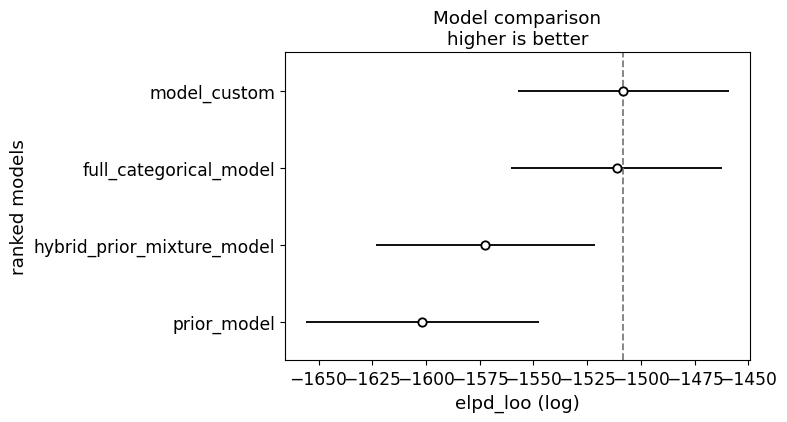

In [12]:
# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

Interestingly, there seems to be a tiny improvement associated with the addition of the interaction between action bias and decision values, though it is quite minor. Let's have a look at the estimated parameters to understand it better:

/tmp/ipykernel_306657/1562303430.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


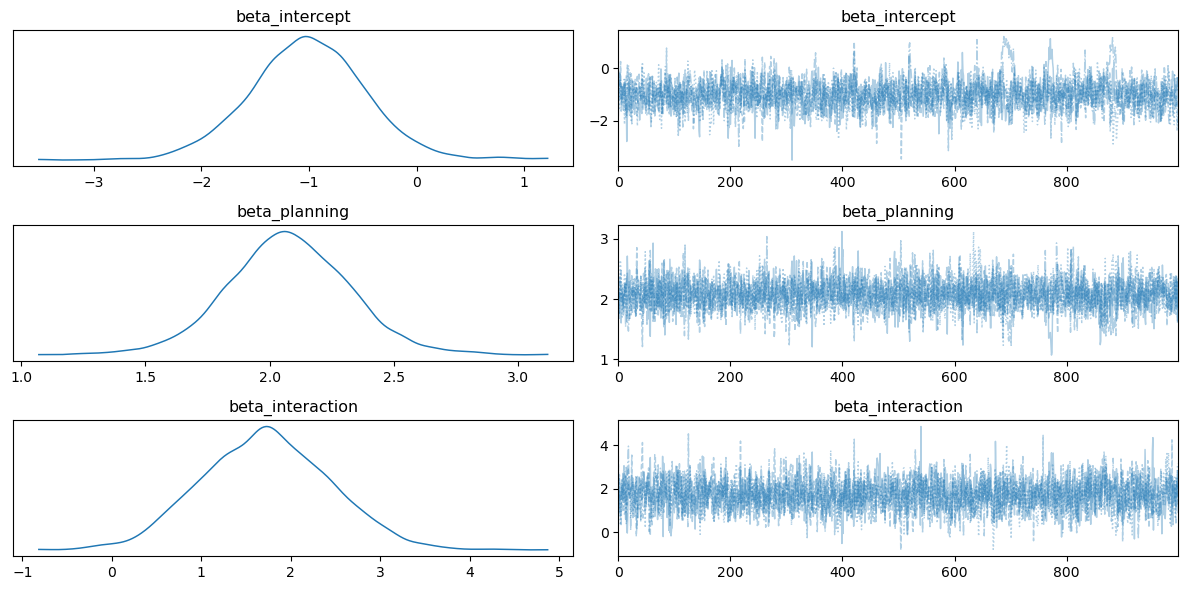

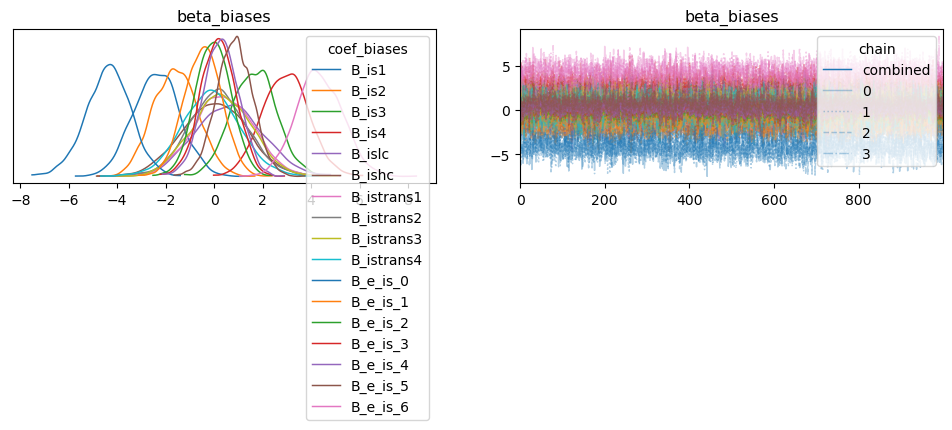

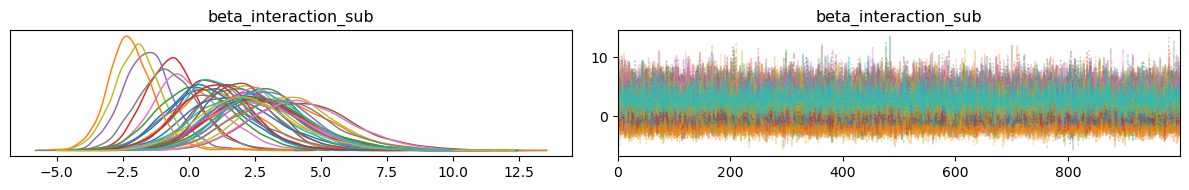

In [20]:
az.plot_trace(traces['model_custom'], 
              var_names=["beta_intercept", "beta_planning", "beta_interaction"],
              combined=True)
plt.tight_layout()

az.plot_trace(traces['model_custom'], 
              var_names=["beta_biases"],
              combined=True, legend=True)
plt.tight_layout()


az.plot_trace(traces['model_custom'], 
              var_names=["beta_interaction_sub"],
              combined=True, legend=False)
plt.tight_layout()

In line with our prediction, the population level beta for the interaction term is centered around 2, indicating a positive slope between entropy and the decision values. This indicates that when entropy of the bias is high (larger uncertainty over action given the prior), so is the weight put on decision values. In other words, this supports the hypothesis that if priors are precise for a specific state, participants tend to rely less on the planning part, as we had predicted. 


# Discussion

These results are quite interesting, as it does suggest that participants fall back on planning if they can't really make out what the best decision is from their priors alone, and vice versa. This is also quite consistent with Sarah's paper showing that the extent to which participants engage in planning depends on their priors and could be taken as a case that the participants bias does indeed reflect a prior. 

But yet again, it will probably be a bit tough to convince a reviewer that we have found something new and exciting when showing that the model that fits the data the best is just one with decision values combined with categorical regressors associated with all aspects of the task (except time, which I so far haven't considered). 

There is however one more thing we can try. So far, we have compared a model in which the priors are fixed, against one where biases are estimated from the data themselves. We can however have an additional model in which the priors themselves get estimated as part of the fitting and then passed through a logit function to model participants data. That would be a two level modelling with latent variables of the kind we have done to investigate the interaction between the bias and the decision values. It is not very likely that it will give us a better fit than the one with categorical variables, because it is essentially very much the same just with an added conversion from probability space to continuous scale, but that's worth a shot.